In [1]:
import sys
import os
from pathlib import Path

from section_identification.section_detector import automatic_identification

package_path = Path(os.path.abspath(""))
apply_filtering = True

example1 = package_path / "images/example1.png"
example2 = package_path / "images/example2.png"
example3 = package_path / "images/example3.png"
example4 = package_path / "images/example4.png"

# the weights can be downloaded from: https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
checkpoint = package_path.parents[0] / "checkpoint/sam_vit_h_4b8939.pth" 


Image shape: (4999, 5000, 3)
Loaded cached masks.
Filtering masks...
Most common largest cluster size: 6 out of 41 total masks.
Chosen parameters: eps=320.0, min_samples=1
Filtering completed with chosen parameters: (np.float64(320.0), 1)


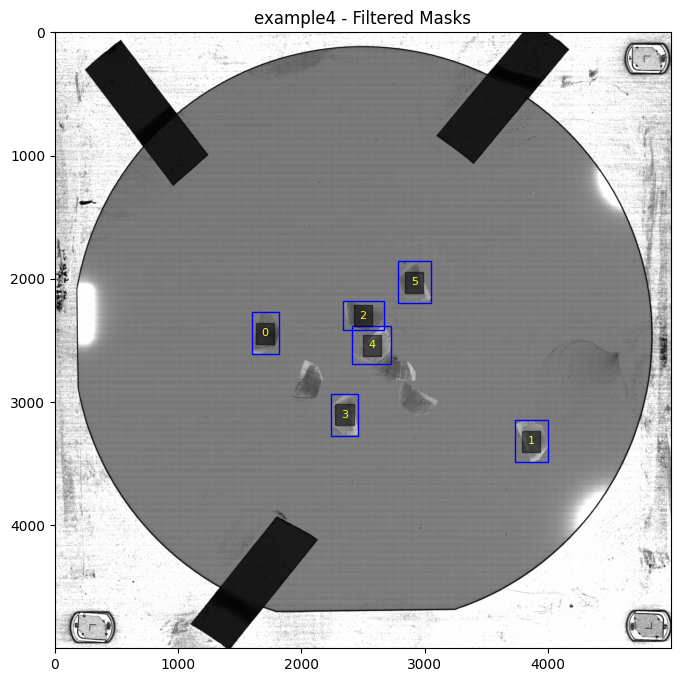

Time taken to run automatic_identification for example4.png: 0.88 seconds
Number of masks identified: 6


In [4]:
# Write filtering=True to only identify sections
masks = automatic_identification(example4, checkpoint=checkpoint, compress=False, apply_filtering=True, visualize=True)
print(f"Number of masks identified: {len(masks)}")

In [5]:
from section_identification.interactive import run_sam_interactive

new_masks, stored_masks, fiducials = run_sam_interactive(example4, checkpoint, masks, model_type="vit_h", device="cpu")

Quantized ONNX model already exists: /Users/fredericoaraujo/Documents/section_identification/images/example4_files/example4_onnx_quantized.onnx
[Info] Embedding already exists: /Users/fredericoaraujo/Documents/section_identification/images/example4_files/example4_embedding.npy
Image size: 5000x4999 (width x height), samScale: 0.205
[Info] Starting interactive segmentation. Move the mouse over the image to update mask.


2025-06-30 17:15:58.637 python[9922:776634] +[IMKClient subclass]: chose IMKClient_Modern
2025-06-30 17:15:58.637 python[9922:776634] +[IMKInputSession subclass]: chose IMKInputSession_Modern


[Info] Exiting interactive segmentation.


Exported mask coordinates to /Users/fredericoaraujo/Documents/section_identification/images/example4_files/example4_mask_coordinates.csv


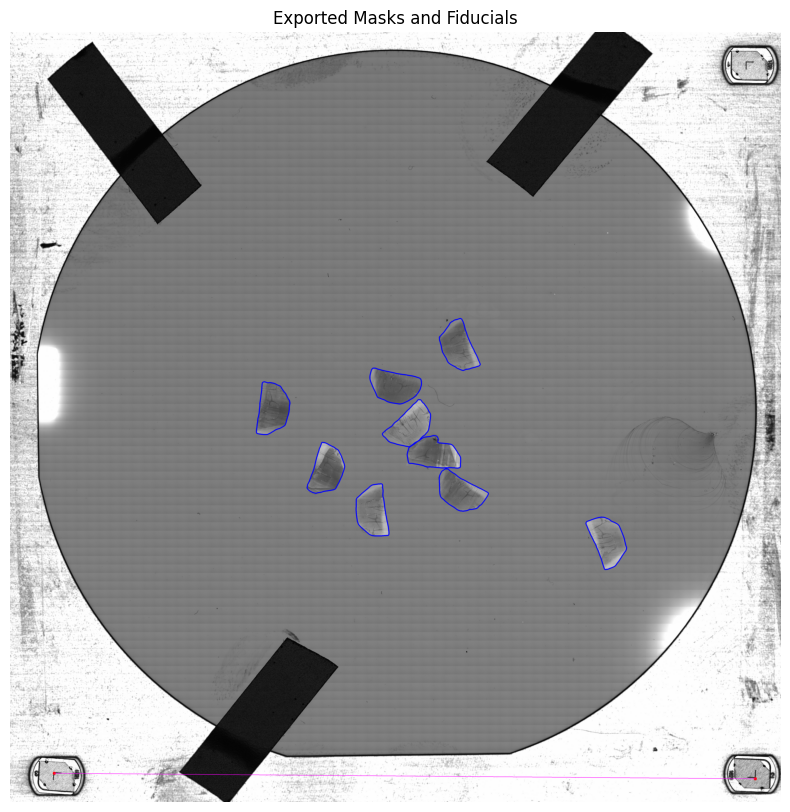

In [ ]:
from section_identification.export import export_mask_coordinates
csv_path = export_mask_coordinates(example4, new_masks, stored_masks, fiducials, visualize=True, sample_points=None)